In [38]:
import geopandas as gpd
import numpy as np
import osmnx as ox
import matplotlib as plt

In [3]:
# Download city boundaries
place = "Tampa, Florida, USA"
boundary = ox.geocode_to_gdf(place)

In [4]:
# Download the road map data
graph = ox.graph_from_place(place, network_type="drive")

# Project the graph to local UTM -> avoiding distortion
graph_proj = ox.project_graph(graph)

In [18]:
# Generating 300 random (x,y) points in inside Tampa boundaries
min_x, min_y, max_x, max_y = boundary.total_bounds

points = []

while len(points) < 300:
    x = np.random.uniform(min_x, max_x)
    y = np.random.uniform(min_y, max_y)
    p = gpd.points_from_xy([x],[y])[0]

    if p.within(boundary.geometry.iloc[0]):
        points.append(p)


<Axes: >

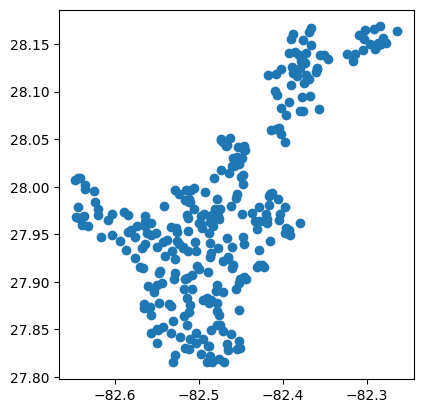

In [23]:
# Creating a GDF 
delivery_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")
delivery_gdf.plot()

In [25]:
# converting to meters for accurate distance math
delivery_gdf_proj = delivery_gdf.to_crs(graph_proj.graph['crs'])

# finding nearest roads Ids (nodes)
nodes = ox.distance.nearest_nodes(
    graph_proj,
    delivery_gdf_proj.geometry.x,
    delivery_gdf_proj.geometry.y)

In [28]:
# create the snapped points IDs -> POINT
snapped_points = [gpd.points_from_xy([graph_proj.nodes[n]['x']],
                                     [graph_proj.nodes[n]['y']])[0]
                for n in nodes]
# create a new GDF for the final locations
snapped_gdf = gpd.GeoDataFrame(geometry=snapped_points, crs=graph_proj.graph['crs'])

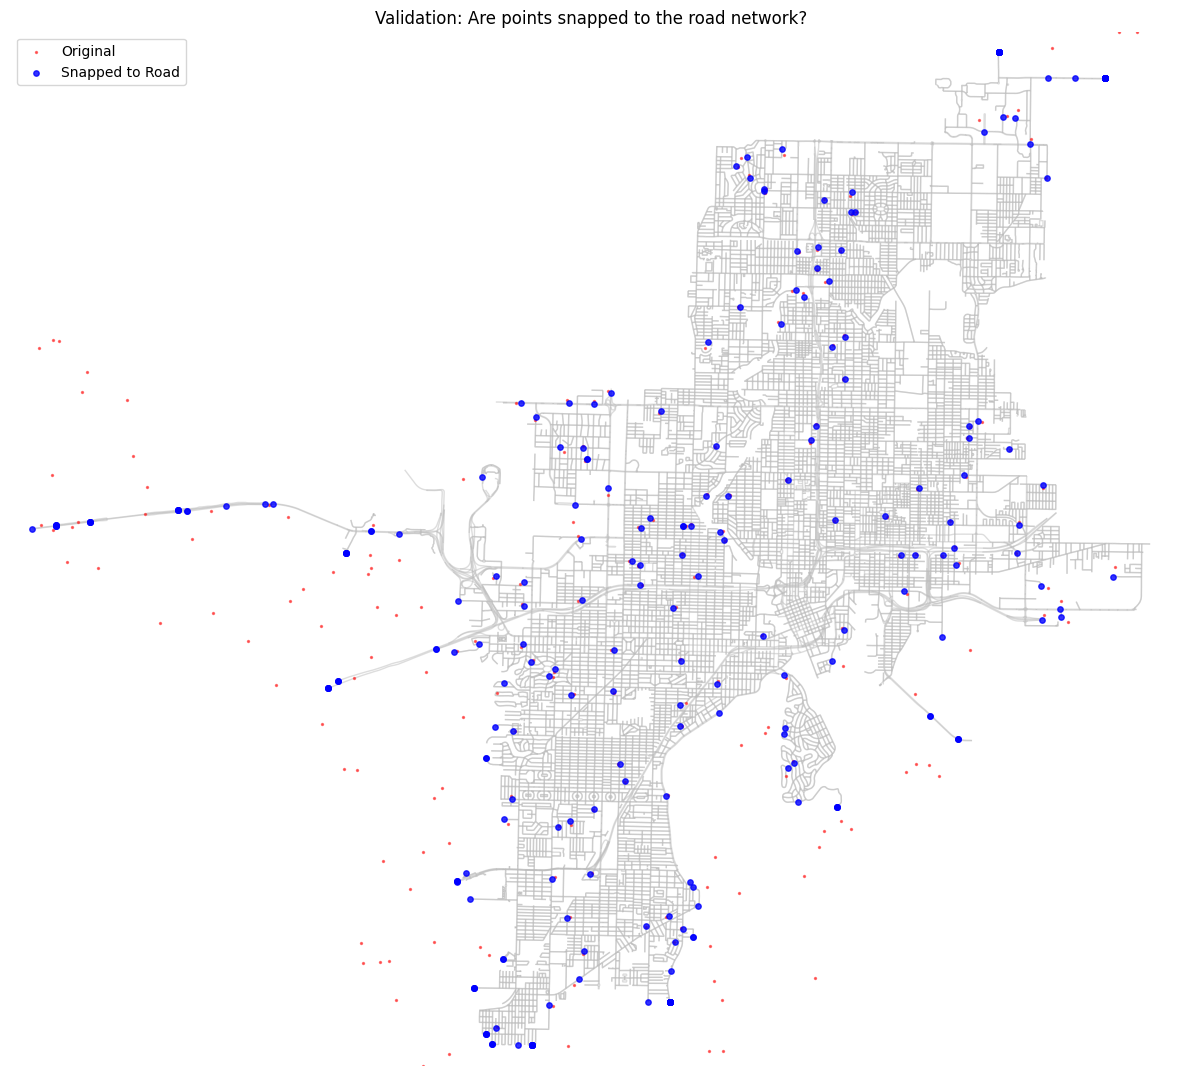

In [ ]:
import matplotlib.pyplot as plt

# 1. Create the figure
fig, ax = plt.subplots(figsize=(15, 15))

# 2. Plot the roads (the 'edges') in a light color
ox.plot_graph(graph_proj, ax=ax, show=False, close=False, edge_color='#bcbcbc', edge_alpha=0.5, node_size=0)

# 3. Plot your original random points in red (small)
delivery_gdf_proj.plot(ax=ax, color='red', markersize=2, alpha=0.5, label='Original')

# 4. Plot your snapped road points in blue (larger)
snapped_gdf.plot(ax=ax, color='blue', markersize=15, alpha=0.8, label='Snapped to Road')

plt.legend()
plt.title("Validation: Are points snapped to the road network?")
plt.show()
